In [10]:
from astropy.io import fits
import numpy as np

file_path = r"C:\Users\mnncs\Downloads\flare stuff\data\go1320170910.fits"

with fits.open(file_path) as hdul:

    data = hdul[2].data

    time_raw = np.asarray(data["TIME"][0], dtype=float)
    flux_raw = np.asarray(data["FLUX"][0], dtype=float)

    flux_raw = flux_raw.reshape(2, -1)

    xrsa = flux_raw[0]
    xrsb = flux_raw[1]

    print("================================================")
    print("FITS TIME DIAGNOSTIC")
    print("================================================")

    print("Number of time points:", len(time_raw))

    print("TIME first 10:")
    print(time_raw[:10])

    print("\nTIME last 10:")
    print(time_raw[-10:])

    print("\nTIME min:", np.nanmin(time_raw))
    print("TIME max:", np.nanmax(time_raw))

    print("\nTime range in hours:",
          (np.nanmax(time_raw) - np.nanmin(time_raw)) / 3600)

    # Positive finite XRS-B
    valid = np.isfinite(xrsb) & (xrsb > 0)

    peak_index = np.argmax(np.where(valid, xrsb, -np.inf))

    print("\n================================================")
    print("FITS XRS-B PEAK")
    print("================================================")

    print("Peak index:", peak_index)
    print("Peak flux:", xrsb[peak_index])

    print("Raw TIME at peak:",
          time_raw[peak_index])

    print("TIME at peak in minutes:",
          time_raw[peak_index] / 60)

    print("TIME at peak in hours:",
          time_raw[peak_index] / 3600)

FITS TIME DIAGNOSTIC
Number of time points: 42188
TIME first 10:
[-0.13100004  1.91899991  3.96499991  6.01199985  8.0619998  10.10899997
 12.15899992 14.20499992 16.25199986 18.30199981]

TIME last 10:
[86379.42499995 86381.4749999  86383.52199984 86385.56900001
 86387.61899996 86389.66499996 86391.71199989 86393.76199985
 86395.80900002 86397.85899997]

TIME min: -0.13100004196166992
TIME max: 86397.85899996758

Time range in hours: 23.999441666669316

FITS XRS-B PEAK
Peak index: 14434
Peak flux: 0.0008996999822556973
Raw TIME at peak: 29560.30900001526
TIME at peak in minutes: 492.67181666692096
TIME at peak in hours: 8.211196944448684



================ FITS FILE STRUCTURE ================

Filename: C:\Users\mnncs\Downloads\flare stuff\data\go1320170910.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      25   ()      
  1  EDGES         1 BinTableHDU     18   1R x 1C   [4E]   
  2  FLUXES        1 BinTableHDU     32   1R x 2C   [42188D, 84376E]   
  3  STATUS        1 BinTableHDU     30   1R x 2C   [1E, 2E]   

================ AVAILABLE COLUMNS ==================

ColDefs(
    name = 'Time'; format = '42188D'; unit = 's'
    name = 'Flux'; format = '84376E'; unit = 'W /m**2'; dim = '(2,42188)'
)

================ DATA SUMMARY ========================

Number of XRS-B samples: 42188
Time range: -0.002183334032694499 to 1439.9643166661263 minutes
XRS-B minimum: 2.2039e-08
XRS-B maximum: 0.0008997


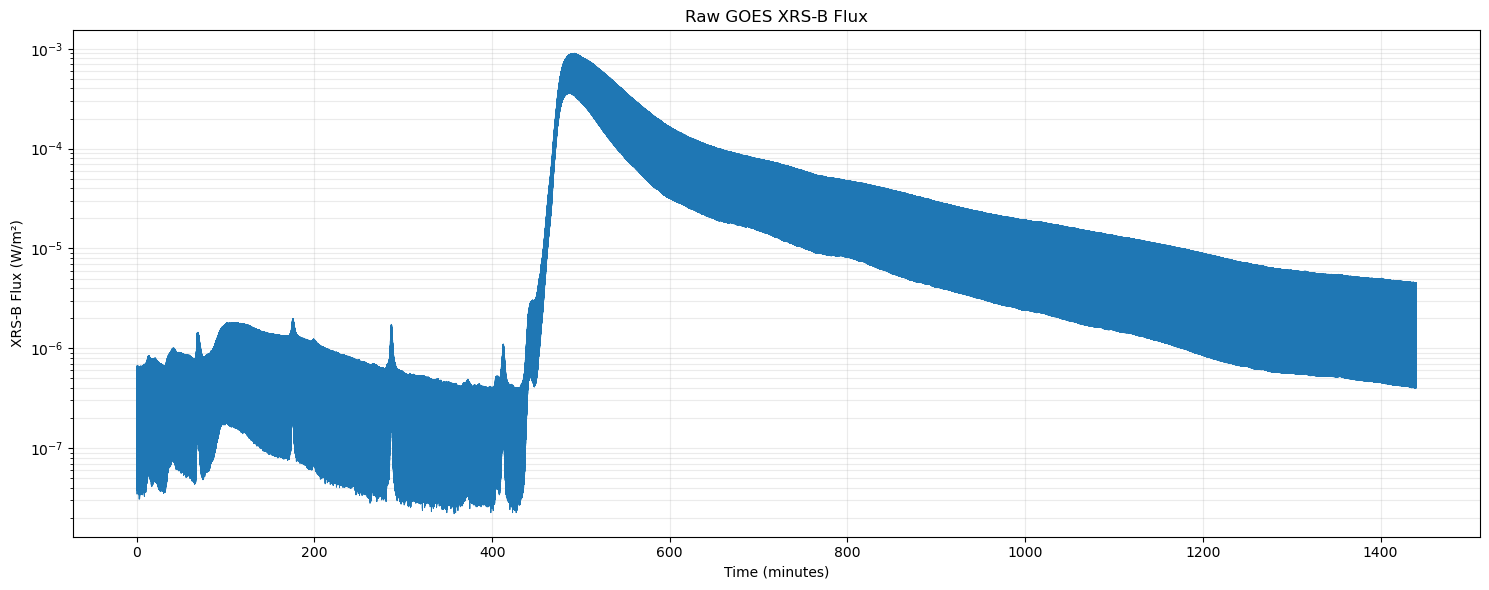


================ SAMPLING ===========================

Median cadence: 2.047000169751527 seconds
Sampling frequency: 0.4885197445398277 Hz

================ POWER SPECTRAL DENSITY =============

Dominant frequency: 5.963375787839694e-05 Hz
Dominant period: 279.4837565100752 minutes


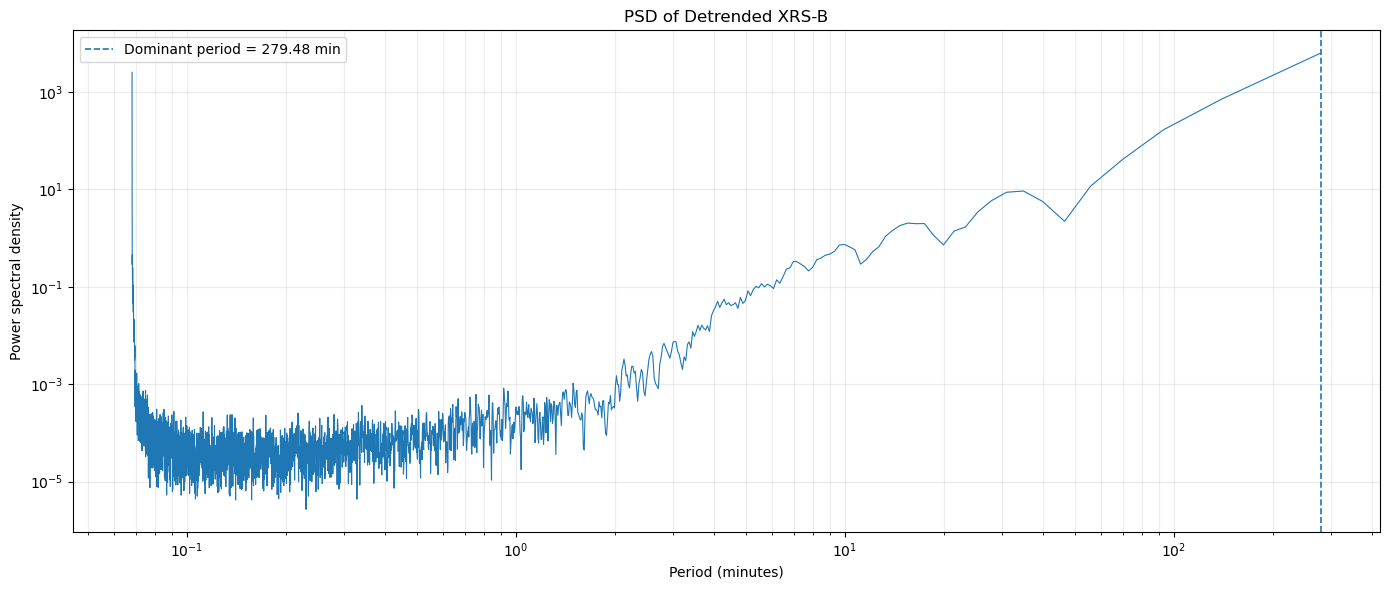


================ WINDOW LENGTH ======================

N = 42188
Dominant period = 279.4837565100752 minutes
Chosen L = 9830 samples
Window duration = 335.3668611442919 minutes
K = N-L+1 = 32359

================ GRAM MATRIX =========================

Logical trajectory matrix: (32359, 9830)
NOT physically copied into memory.
Gram matrix shape: (9830, 9830)

================ EIGENDECOMPOSITION =================

Number of eigenvalues: 9830
Expected: 9830

First 10 eigenvalues:
  1 | λ = 1.654075e+08 | Energy = 0.426627
  2 | λ = 9.243481e+07 | Energy = 0.238412
  3 | λ = 6.762894e+07 | Energy = 0.174432
  4 | λ = 2.896725e+07 | Energy = 0.074714
  5 | λ = 1.426552e+07 | Energy = 0.036794
  6 | λ = 7.052678e+06 | Energy = 0.018191
  7 | λ = 3.595836e+06 | Energy = 0.009275
  8 | λ = 2.124521e+06 | Energy = 0.005480
  9 | λ = 1.410513e+06 | Energy = 0.003638
 10 | λ = 1.068242e+06 | Energy = 0.002755


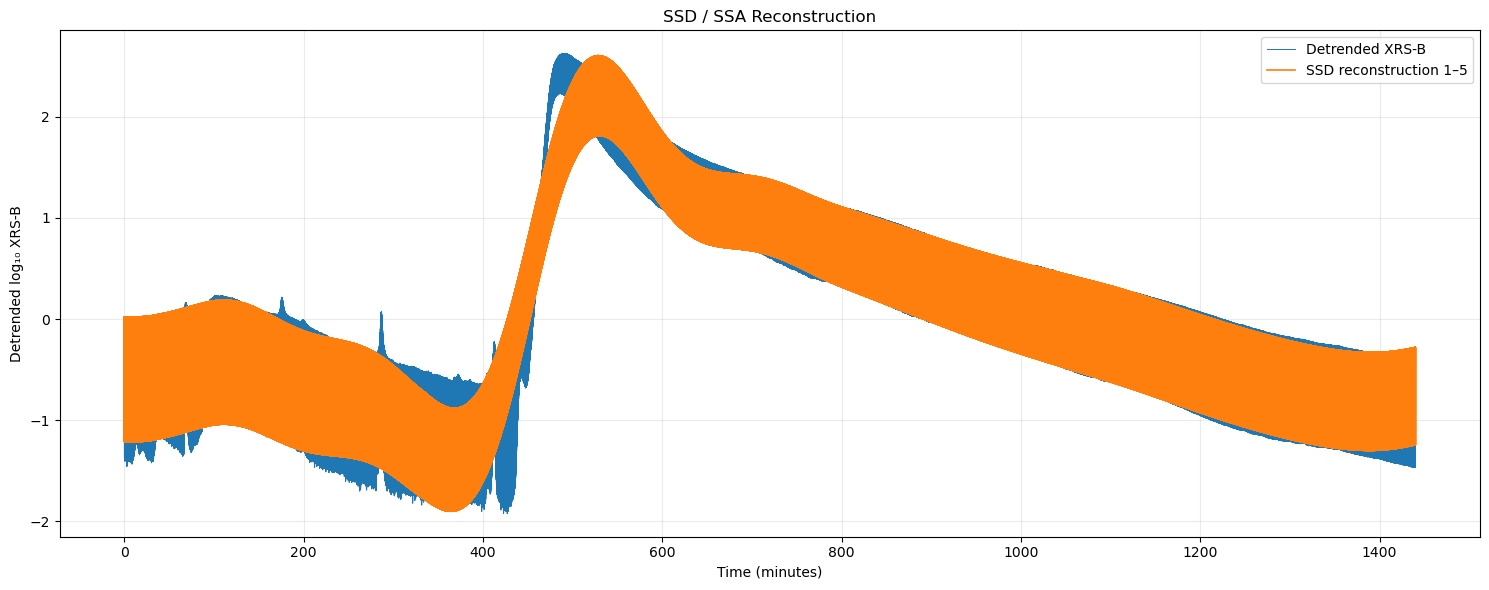

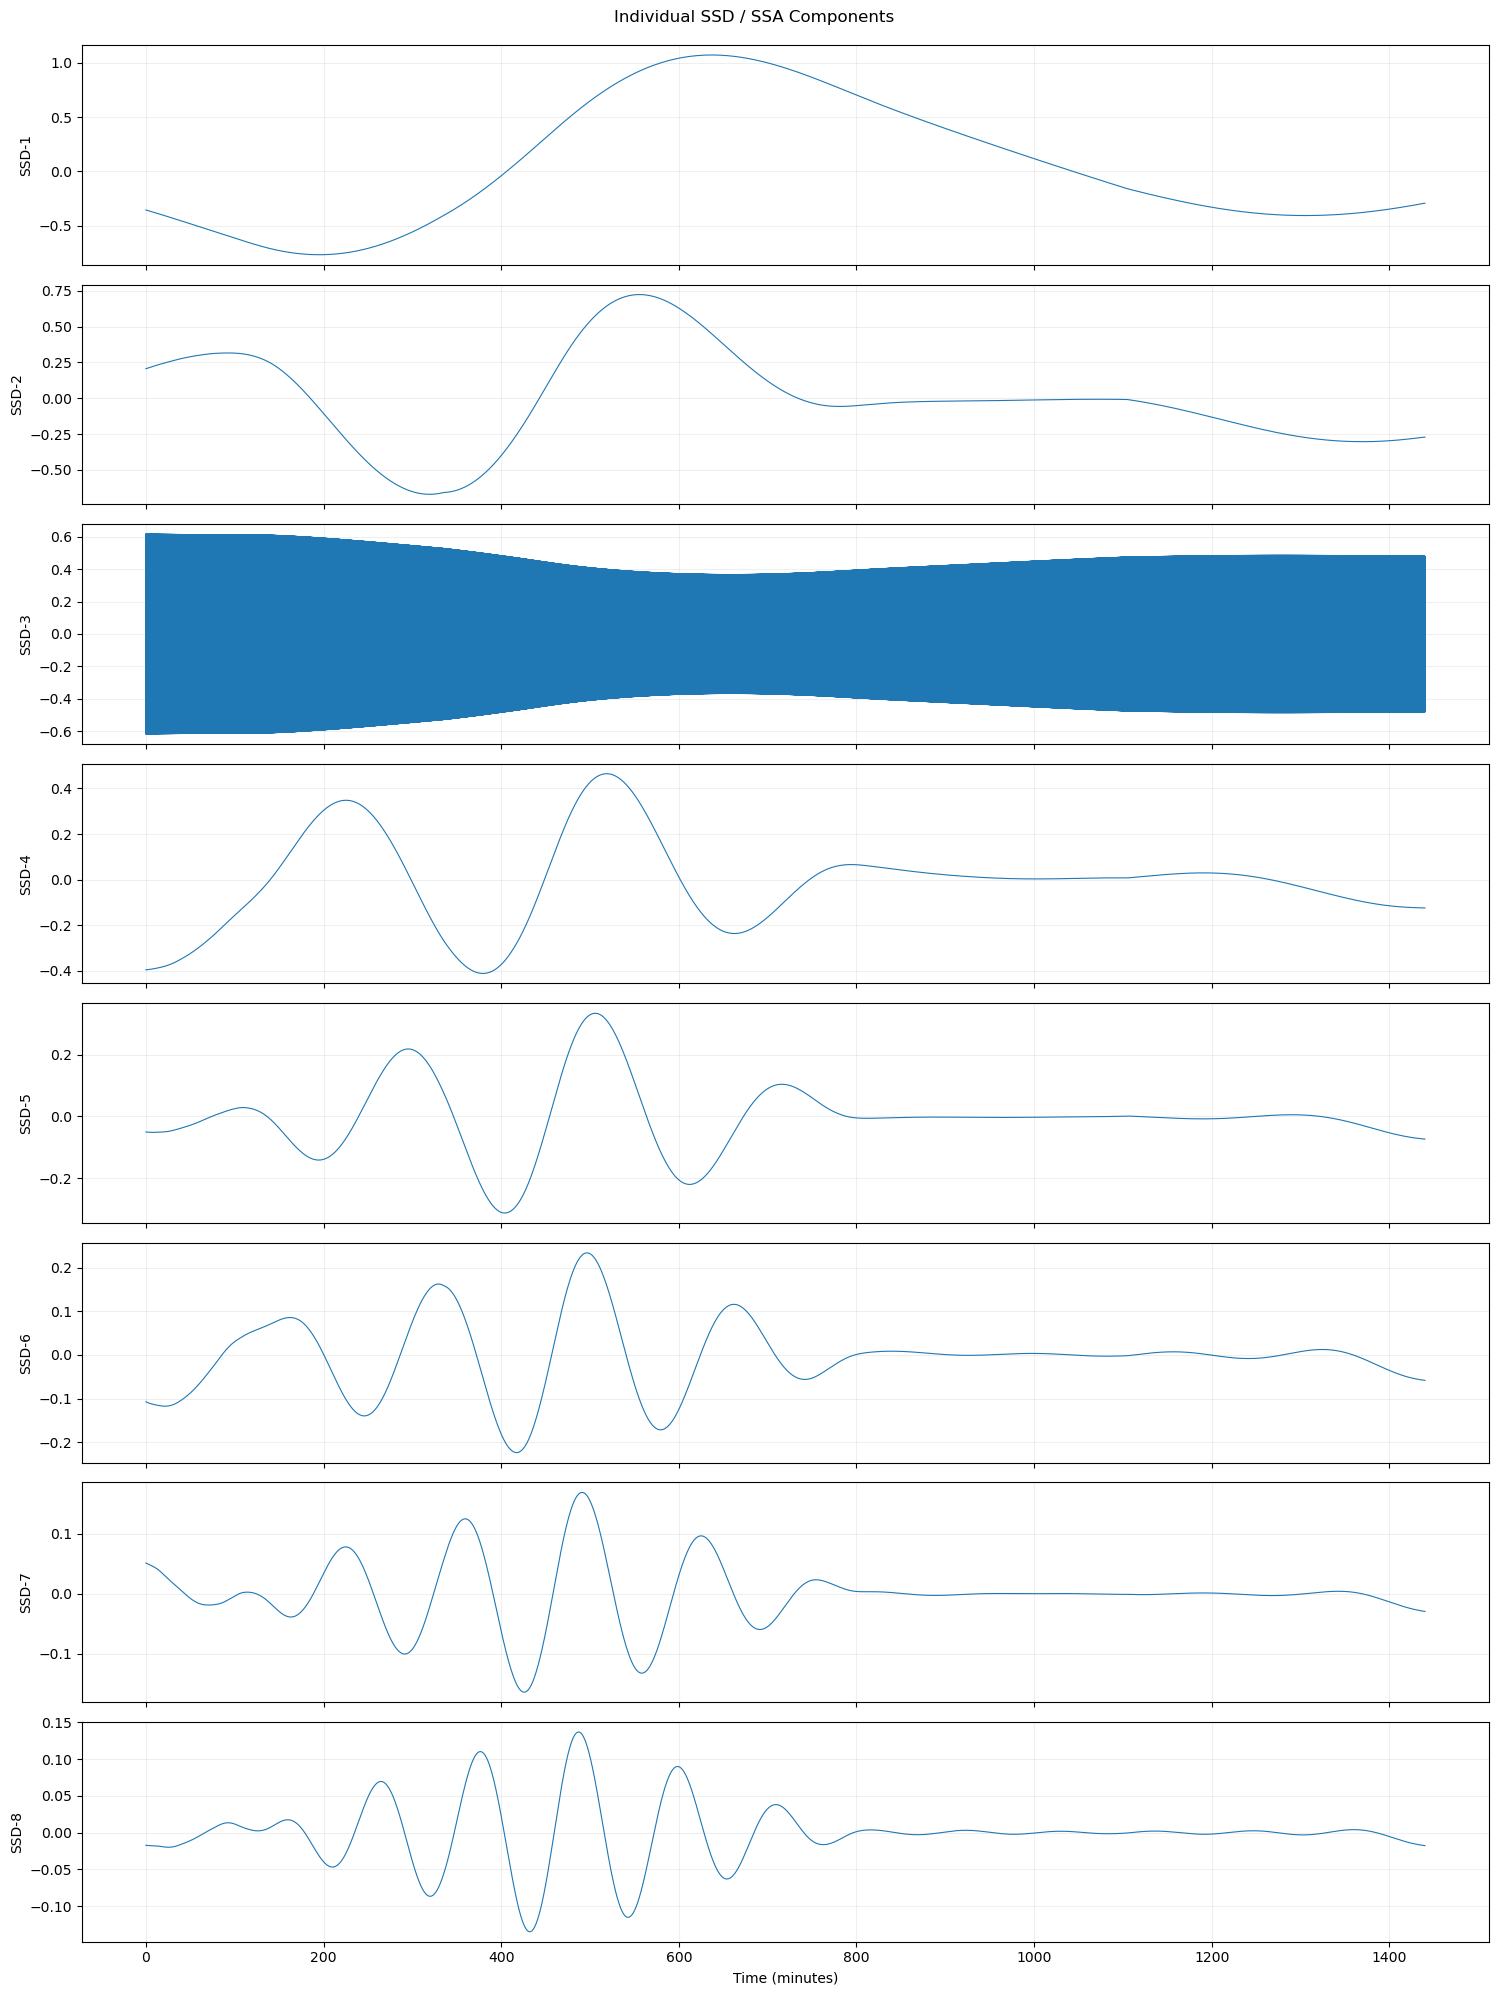

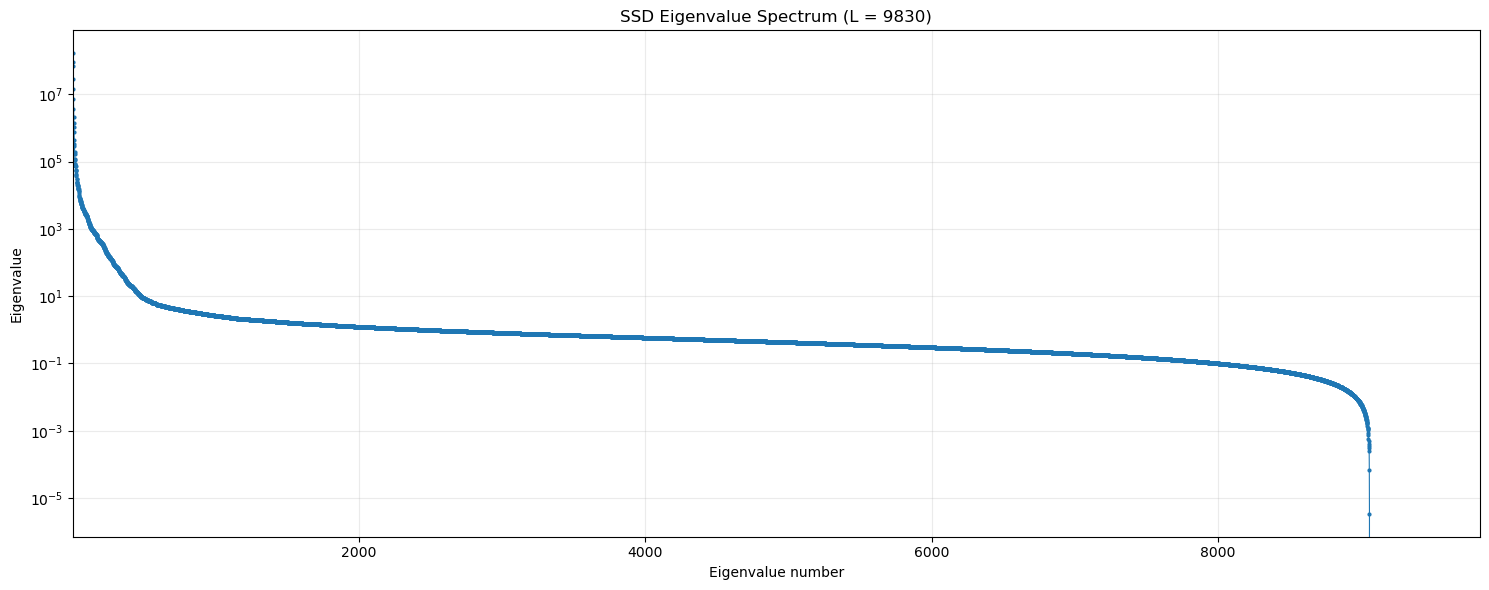


================ FINAL SUMMARY ======================

Number of samples N: 42188
Sampling interval: 2.047000169751527 seconds
Dominant PSD period: 279.4837565100752 minutes
Selected L: 9830
Window duration: 335.3668611442919 minutes
Trajectory dimensions would be: 9830 × 32359
Gram matrix dimensions: 9830 × 9830
Number of eigenvalues: 9830


In [11]:
# ============================================================
# GOES XRS-B → DETREND → PSD → L → GRAM MATRIX → SSD/SSA
#
# Designed for the old GOES FITS format:
#
# hdul[2] = FLUXES
# data[0][0] = time vector
# data[0][1] = combined XRS-A + XRS-B flux
#
# XRS-A = first half
# XRS-B = second half
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from scipy import signal


# ============================================================
# USER INPUT
# ============================================================

file_path = (
    r"C:\Users\mnncs\Downloads\flare stuff\data"
    r"\go1320170910.fits"
)


# ============================================================
# 1. LOAD FITS
# ============================================================

hdul = fits.open(file_path)

print("\n================ FITS FILE STRUCTURE ================\n")
hdul.info()

data = hdul[2].data

print("\n================ AVAILABLE COLUMNS ==================\n")
print(data.columns)


# ============================================================
# 2. EXTRACT TIME + FLUX
# ============================================================

time = np.array(data[0][0]) / 60.0
flux = np.array(data[0][1])


# ============================================================
# 3. SPLIT XRS-A AND XRS-B
# ============================================================

flux = flux.reshape(2, -1)

xrsa = flux[0]
xrsb = flux[1]

signal_raw = xrsb


# ============================================================
# 4. REMOVE INVALID VALUES
# ============================================================

mask = (
    np.isfinite(time)
    & np.isfinite(signal_raw)
    & (signal_raw > 0)
)

time = time[mask]
signal_raw = signal_raw[mask]


print("\n================ DATA SUMMARY ========================\n")

print("Number of XRS-B samples:", len(signal_raw))
print("Time range:", time[0], "to", time[-1], "minutes")
print("XRS-B minimum:", np.min(signal_raw))
print("XRS-B maximum:", np.max(signal_raw))


# ============================================================
# 5. LOG TRANSFORMATION
# ============================================================

signal_log = np.log10(signal_raw)


# ============================================================
# 6. DETREND
# ============================================================

signal_detrended = signal.detrend(
    signal_log,
    type="linear"
)


# ============================================================
# 7. RAW XRS-B PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 6)
)

ax.plot(
    time,
    signal_raw,
    linewidth=0.7
)

ax.set_yscale("log")

ax.set_xlabel(
    "Time (minutes)"
)

ax.set_ylabel(
    "XRS-B Flux (W/m²)"
)

ax.set_title(
    "Raw GOES XRS-B Flux"
)

ax.grid(
    True,
    which="both",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ============================================================
# 8. SAMPLING INTERVAL
# ============================================================

dt_minutes = np.median(
    np.diff(time)
)

dt_seconds = dt_minutes * 60.0

Fs = 1.0 / dt_seconds


print("\n================ SAMPLING ===========================\n")

print(
    "Median cadence:",
    dt_seconds,
    "seconds"
)

print(
    "Sampling frequency:",
    Fs,
    "Hz"
)


# ============================================================
# 9. POWER SPECTRAL DENSITY
# ============================================================

print(
    "\n================ POWER SPECTRAL DENSITY =============\n"
)

nperseg = min(
    8192,
    len(signal_detrended)
)

freq, psd = signal.welch(
    signal_detrended,
    fs=Fs,
    window="hann",
    nperseg=nperseg,
    detrend=False,
    scaling="density"
)


# Remove zero frequency

valid_freq = freq > 0

freq = freq[valid_freq]
psd = psd[valid_freq]


period_minutes = (
    1.0 / freq / 60.0
)


# ============================================================
# 10. PSD RANGE FOR FINDING DOMINANT PERIOD
# ============================================================

MIN_PERIOD = 1.0
MAX_PERIOD = 300.0

psd_mask = (
    (period_minutes >= MIN_PERIOD)
    & (period_minutes <= MAX_PERIOD)
    & np.isfinite(psd)
    & (psd > 0)
)


candidate_periods = period_minutes[psd_mask]
candidate_freq = freq[psd_mask]
candidate_psd = psd[psd_mask]


peak_index = np.argmax(
    candidate_psd
)

dominant_period = candidate_periods[
    peak_index
]

dominant_frequency = candidate_freq[
    peak_index
]


print(
    "Dominant frequency:",
    dominant_frequency,
    "Hz"
)

print(
    "Dominant period:",
    dominant_period,
    "minutes"
)


# ============================================================
# 11. PSD PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.loglog(
    period_minutes,
    psd,
    linewidth=0.8
)

ax.axvline(
    dominant_period,
    linestyle="--",
    linewidth=1.2,
    label=(
        f"Dominant period = "
        f"{dominant_period:.2f} min"
    )
)

ax.set_xlabel(
    "Period (minutes)"
)

ax.set_ylabel(
    "Power spectral density"
)

ax.set_title(
    "PSD of Detrended XRS-B"
)

ax.grid(
    True,
    which="both",
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 12. DETERMINE SSA WINDOW LENGTH L
# ============================================================
#
# Characteristic period → number of samples
#
# L ≈ 1.2 × period / dt
# ============================================================

L = int(
    np.ceil(
        1.2
        * dominant_period
        / dt_minutes
    )
)


# ============================================================
# MEMORY SAFETY
# ============================================================

N = len(signal_detrended)

max_L = int(
    0.45 * N
)

L = min(
    L,
    max_L
)

L = max(
    L,
    10
)


# Make L even

if L % 2 != 0:
    L -= 1


K = N - L + 1


print("\n================ WINDOW LENGTH ======================\n")

print("N =", N)

print(
    "Dominant period =",
    dominant_period,
    "minutes"
)

print(
    "Chosen L =",
    L,
    "samples"
)

print(
    "Window duration =",
    L * dt_minutes,
    "minutes"
)

print(
    "K = N-L+1 =",
    K
)


# ============================================================
# 13. GRAM MATRIX
# ============================================================
#
# We do NOT construct:
#
#     X = L × K
#
# Instead:
#
#     G = X Xᵀ
#
# where G is only L × L.
# ============================================================

print(
    "\n================ GRAM MATRIX =========================\n"
)

windows = np.lib.stride_tricks.sliding_window_view(
    signal_detrended,
    L
)

print(
    "Logical trajectory matrix:",
    windows.shape
)

print(
    "NOT physically copied into memory."
)


G = np.zeros(
    (L, L),
    dtype=np.float64
)


# Small chunks prevent excessive temporary RAM use

CHUNK_SIZE = 5000


for start in range(
    0,
    K,
    CHUNK_SIZE
):

    stop = min(
        start + CHUNK_SIZE,
        K
    )

    W = windows[start:stop]

    G += W.T @ W


# Force exact symmetry

G = (
    G + G.T
) / 2.0


print(
    "Gram matrix shape:",
    G.shape
)


# ============================================================
# 14. EIGENDECOMPOSITION
# ============================================================

print(
    "\n================ EIGENDECOMPOSITION =================\n"
)

eigenvalues, eigenvectors = np.linalg.eigh(
    G
)


# Sort largest → smallest

order = np.argsort(
    eigenvalues
)[::-1]

eigenvalues = eigenvalues[order]

eigenvectors = eigenvectors[
    :,
    order
]


# Prevent tiny numerical negatives

eigenvalues = np.maximum(
    eigenvalues,
    0
)


print(
    "Number of eigenvalues:",
    len(eigenvalues)
)

print(
    "Expected:",
    L
)


# ============================================================
# 15. ENERGY FRACTION
# ============================================================

energy_fraction = (
    eigenvalues
    / np.sum(eigenvalues)
)

cumulative_energy = np.cumsum(
    energy_fraction
)


print("\nFirst 10 eigenvalues:")

for i in range(
    min(10, L)
):

    print(
        f"{i + 1:3d} | "
        f"λ = {eigenvalues[i]:.6e} | "
        f"Energy = {energy_fraction[i]:.6f}"
    )


# ============================================================
# 16. SSD / SSA RECONSTRUCTION
# ============================================================

N_COMPONENTS = min(
    8,
    L
)

RC = np.zeros(
    (
        N_COMPONENTS,
        N
    )
)


# ============================================================
# DIAGONAL AVERAGING COUNTS
# ============================================================

counts = np.zeros(
    N
)

for i in range(L):

    counts[
        i:i + K
    ] += 1


# ============================================================
# RECONSTRUCT EACH ELEMENTARY COMPONENT
# ============================================================

for component in range(
    N_COMPONENTS
):

    lam = eigenvalues[
        component
    ]

    if lam <= 0:
        continue

    sigma = np.sqrt(
        lam
    )

    u = eigenvectors[
        :,
        component
    ]

    # --------------------------------------------------------
    # Calculate Xᵀu without building X
    # --------------------------------------------------------

    v = np.zeros(
        K
    )

    for start in range(
        0,
        K,
        CHUNK_SIZE
    ):

        stop = min(
            start + CHUNK_SIZE,
            K
        )

        W = windows[
            start:stop
        ]

        v[
            start:stop
        ] = W @ u

    v /= sigma

    # --------------------------------------------------------
    # Elementary matrix:
    #
    # E = σ u vᵀ
    #
    # Diagonal averaging via convolution
    # --------------------------------------------------------

    diagonal_sum = (
        sigma
        * np.convolve(
            u,
            v,
            mode="full"
        )
    )

    RC[
        component
    ] = (
        diagonal_sum
        / counts
    )


# ============================================================
# 17. RECONSTRUCT FIRST COMPONENTS
# ============================================================

N_RECON = min(
    5,
    N_COMPONENTS
)

reconstruction = np.sum(
    RC[:N_RECON],
    axis=0
)


# ============================================================
# 18. SSD RECONSTRUCTION PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 6)
)

ax.plot(
    time,
    signal_detrended,
    linewidth=0.7,
    label="Detrended XRS-B"
)

ax.plot(
    time,
    reconstruction,
    linewidth=1.2,
    label=(
        f"SSD reconstruction 1–{N_RECON}"
    )
)

ax.set_xlabel(
    "Time (minutes)"
)

ax.set_ylabel(
    "Detrended log₁₀ XRS-B"
)

ax.set_title(
    "SSD / SSA Reconstruction"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 19. INDIVIDUAL SSD COMPONENTS
# ============================================================

fig, axes = plt.subplots(
    N_COMPONENTS,
    1,
    figsize=(
        15,
        2.5 * N_COMPONENTS
    ),
    sharex=True
)


if N_COMPONENTS == 1:
    axes = [axes]


for i in range(
    N_COMPONENTS
):

    axes[i].plot(
        time,
        RC[i],
        linewidth=0.8
    )

    axes[i].set_ylabel(
        f"SSD-{i + 1}"
    )

    axes[i].grid(
        True,
        alpha=0.2
    )


axes[-1].set_xlabel(
    "Time (minutes)"
)

fig.suptitle(
    "Individual SSD / SSA Components",
    y=0.995
)

plt.tight_layout()
plt.show()


# ============================================================
# 20. NORMAL EIGENVALUE SPECTRUM
# ============================================================

component_number = np.arange(
    1,
    L + 1
)


fig, ax = plt.subplots(
    figsize=(15, 6)
)

ax.semilogy(
    component_number,
    eigenvalues,
    linewidth=0.8,
    marker="o",
    markersize=2
)

ax.set_xlim(
    1,
    L
)

ax.set_xlabel(
    "Eigenvalue number"
)

ax.set_ylabel(
    "Eigenvalue"
)

ax.set_title(
    f"SSD Eigenvalue Spectrum (L = {L})"
)

ax.grid(
    True,
    which="both",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print(
    "\n================ FINAL SUMMARY ======================\n"
)

print(
    "Number of samples N:",
    N
)

print(
    "Sampling interval:",
    dt_seconds,
    "seconds"
)

print(
    "Dominant PSD period:",
    dominant_period,
    "minutes"
)

print(
    "Selected L:",
    L
)

print(
    "Window duration:",
    L * dt_minutes,
    "minutes"
)

print(
    "Trajectory dimensions would be:",
    L,
    "×",
    K
)

print(
    "Gram matrix dimensions:",
    L,
    "×",
    L
)

print(
    "Number of eigenvalues:",
    len(eigenvalues)
)
